# Processed Data Verification & EDA
This notebook verifies the integrity of the modular Parquet components and performs basic EDA on the engineered technical features.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.data.data_module import DataModule

### 1. Load Modular Components via DataModule

In [2]:
PROCESSED_DIR = "../data/processed_market"
dm = DataModule(PROCESSED_DIR)

# Load and join features, targets, and metadata
df = dm.prepare_dataset(components=["technical_features", "targets", "metadata"])
df.sort_index(inplace=True)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset prepared successfully: 30443 rows.
Dataset loaded: 30443 rows, 46 columns


,TRIX_30_9,VWAP_D,ROC_10,RSI_14,ATRr_14,MFI_14,EFI_13,BBB_5_2.0_2.0,BBP_5_2.0_2.0,KCBe_20_2,...,Target_24h_1.0x_TBM,Target_24h_1.5x_TBM,Target_24h_2.0x_TBM,Target_24h_2.5x_TBM,Target_24h_3.0x_TBM,Open,High,Low,Close,Volume
time,,,,,,,,,,,,,,,,,,,,,
2021-05-06 21:00:00+00:00,0.001164,1.203869,0.093767,67.686906,0.001085,79.619024,0.289243,0.129086,0.641314,1.204435,...,0.0,0.0,0.0,0.0,0.0,1.20646,1.20650,1.20572,1.20625,181
2021-05-06 22:00:00+00:00,0.001674,1.203904,0.031517,66.098464,0.001036,75.731214,0.234666,0.109865,0.474342,1.204592,...,0.0,0.0,0.0,0.0,0.0,1.20625,1.20633,1.20594,1.20609,580
2021-05-06 23:00:00+00:00,0.002173,1.203923,0.024042,68.207597,0.001000,73.300545,0.217762,0.047895,0.818463,1.204775,...,0.0,0.0,0.0,0.0,0.0,1.20609,1.20660,1.20606,1.20651,277
2021-05-07 00:00:00+00:00,0.002651,1.206480,0.032339,66.510029,0.000990,80.421015,0.163362,0.047564,0.548800,1.204925,...,0.0,0.0,0.0,0.0,0.0,1.20651,1.20697,1.20612,1.20635,1019
2021-05-07 01:00:00+00:00,0.003112,1.206439,0.139431,67.752491,0.000969,73.360792,0.175642,0.058553,0.817119,1.205083,...,0.0,0.0,0.0,0.0,0.0,1.20634,1.20666,1.20596,1.20658,1084


In [3]:
for c in df.columns:
    if c.startswith("Target"):
        print(c)

Target_5h_1.0x_TBM
Target_5h_1.5x_TBM
Target_5h_2.0x_TBM
Target_5h_2.5x_TBM
Target_5h_3.0x_TBM
Target_12h_1.0x_TBM
Target_12h_1.5x_TBM
Target_12h_2.0x_TBM
Target_12h_2.5x_TBM
Target_12h_3.0x_TBM
Target_24h_1.0x_TBM
Target_24h_1.5x_TBM
Target_24h_2.0x_TBM
Target_24h_2.5x_TBM
Target_24h_3.0x_TBM


In [4]:
# Calculate class distribution for each target column
for col in df.columns:
    if col.startswith("Target"):
        print(f"\nDistribution for {col}:")
        counts = df[col].value_counts(normalize=True).sort_index()
        labels = ["Buy (0)", "Sell (1)", "Neutral (2)"]
        for i, val in enumerate(counts):
            print(f"  {labels[i]}: {val:.2%}")


Distribution for Target_5h_1.0x_TBM:
  Buy (0): 28.48%
  Sell (1): 28.95%
  Neutral (2): 42.57%

Distribution for Target_5h_1.5x_TBM:
  Buy (0): 17.68%
  Sell (1): 18.31%
  Neutral (2): 64.01%

Distribution for Target_5h_2.0x_TBM:
  Buy (0): 11.12%
  Sell (1): 11.78%
  Neutral (2): 77.10%

Distribution for Target_5h_2.5x_TBM:
  Buy (0): 7.18%
  Sell (1): 7.61%
  Neutral (2): 85.21%

Distribution for Target_5h_3.0x_TBM:
  Buy (0): 4.75%
  Sell (1): 5.05%
  Neutral (2): 90.20%

Distribution for Target_12h_1.0x_TBM:
  Buy (0): 43.44%
  Sell (1): 43.82%
  Neutral (2): 12.75%

Distribution for Target_12h_1.5x_TBM:
  Buy (0): 33.95%
  Sell (1): 35.06%
  Neutral (2): 30.99%

Distribution for Target_12h_2.0x_TBM:
  Buy (0): 25.55%
  Sell (1): 26.92%
  Neutral (2): 47.53%

Distribution for Target_12h_2.5x_TBM:
  Buy (0): 19.32%
  Sell (1): 20.51%
  Neutral (2): 60.17%

Distribution for Target_12h_3.0x_TBM:
  Buy (0): 14.50%
  Sell (1): 15.55%
  Neutral (2): 69.96%

Distribution for Target_24h_

### 2. Alignment & Integrity Sanity Checks

In [5]:
# 1. Check for missing values (there should be none after processing)
nan_counts = df.isna().sum().sum()
print(f"Total NaNs in dataset: {nan_counts}")

# 2. Check time continuity (hourly data)
time_diffs = df.index.to_series().diff().dt.total_seconds() / 3600
print(f"Max time gap: {time_diffs.max()} hours")
print(f"Average time gap (excluding weekends): {time_diffs[time_diffs < 48].mean():.2f} hours")

# 3. Target Distribution
target_col = "Target_5h_TBM"
if target_col in df.columns:
    print(f"\nDistribution for {target_col}:")
    counts = df[target_col].value_counts(normalize=True).sort_index()
    labels = ["Profit (0)", "Loss (1)", "Timeout (2)"]
    for i, val in enumerate(counts):
        print(f"  {labels[i]}: {val:.2%}")

Total NaNs in dataset: 0
Max time gap: 73.0 hours
Average time gap (excluding weekends): 1.00 hours


### 3. Visualizing Technical Indicators & Price

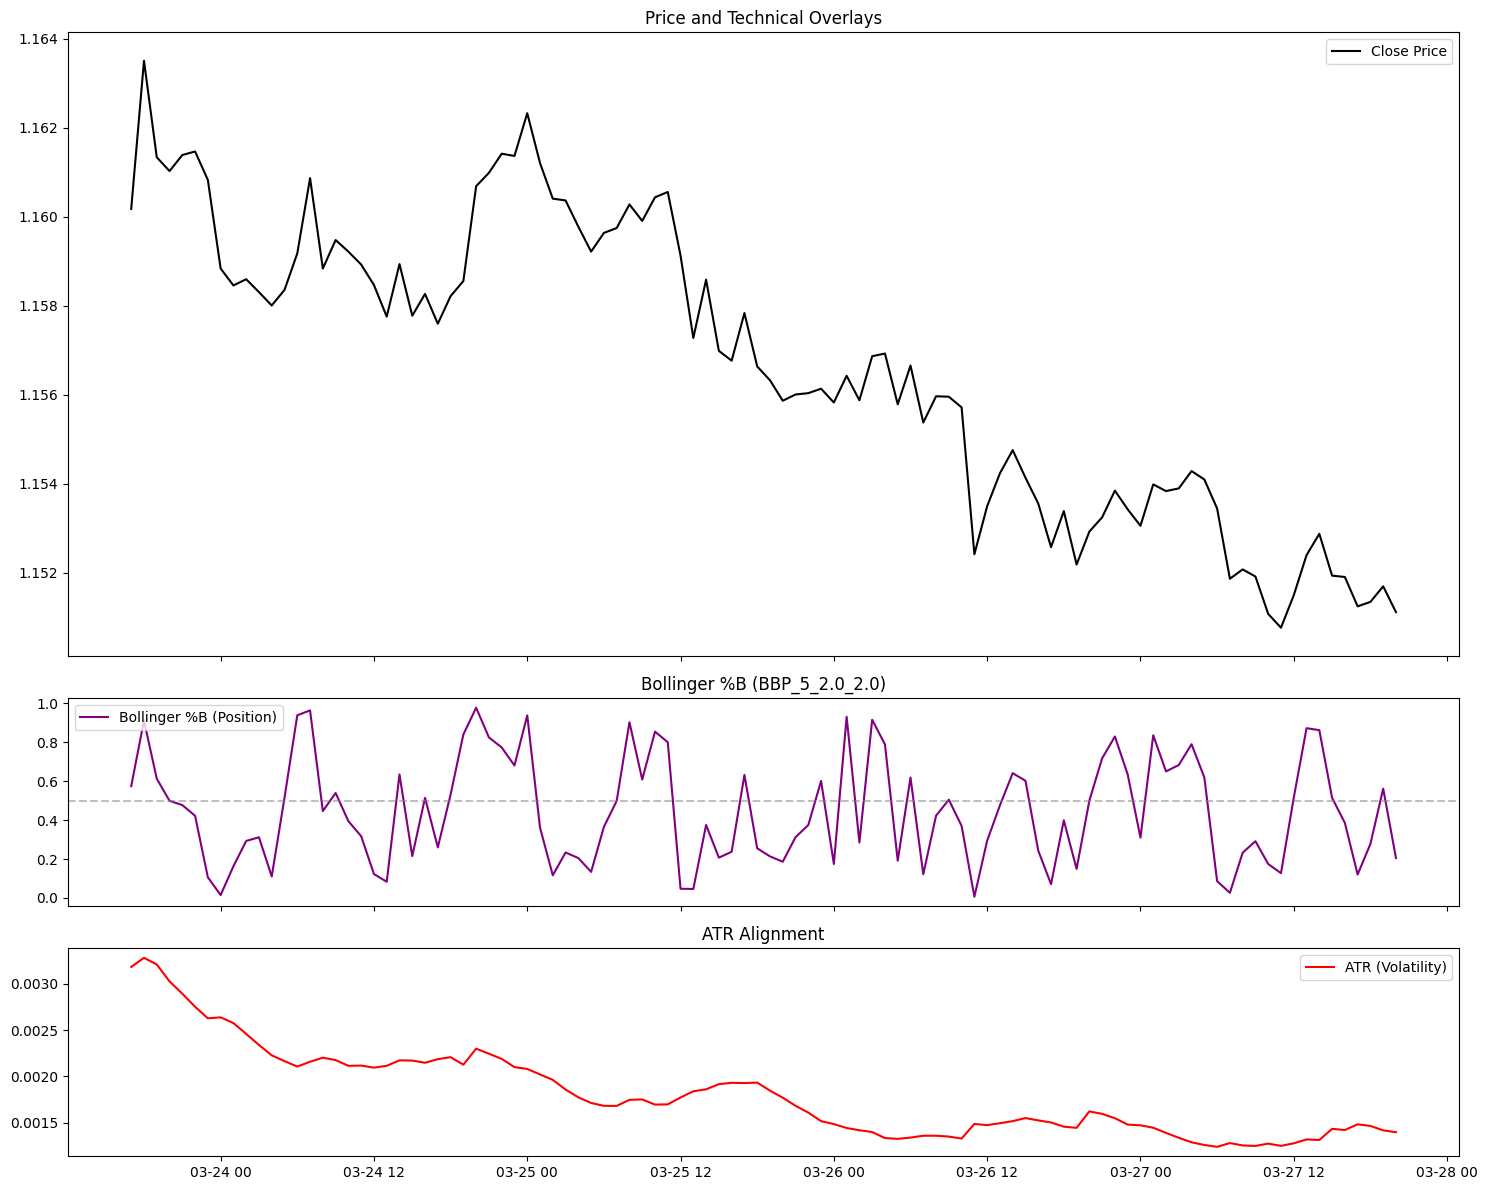

In [6]:
# Plot last 100 periods for visual confirmation of ATR and Bollinger Band features
plot_df = df.tail(100)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Price Plot
ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black')
ax1.set_title("Price and Technical Overlays")
ax1.legend()

# Bollinger %B (BBP) - Stationary relative position
bb_col = [c for c in df.columns if "BBP" in c][0] if any("BBP" in c for c in df.columns) else None
if bb_col:
    ax2.plot(plot_df.index, plot_df[bb_col], label='Bollinger %B (Position)', color='purple')
    ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
    ax2.set_title(f"Bollinger %B ({bb_col})")
    ax2.legend()

# ATR Plot
if 'ATRr_14' in df.columns:
    ax3.plot(plot_df.index, plot_df['ATRr_14'], label='ATR (Volatility)', color='red')
    ax3.set_title("ATR Alignment")
    ax3.legend()

plt.tight_layout()
plt.show()

### 4. Indicator Correlation Matrix

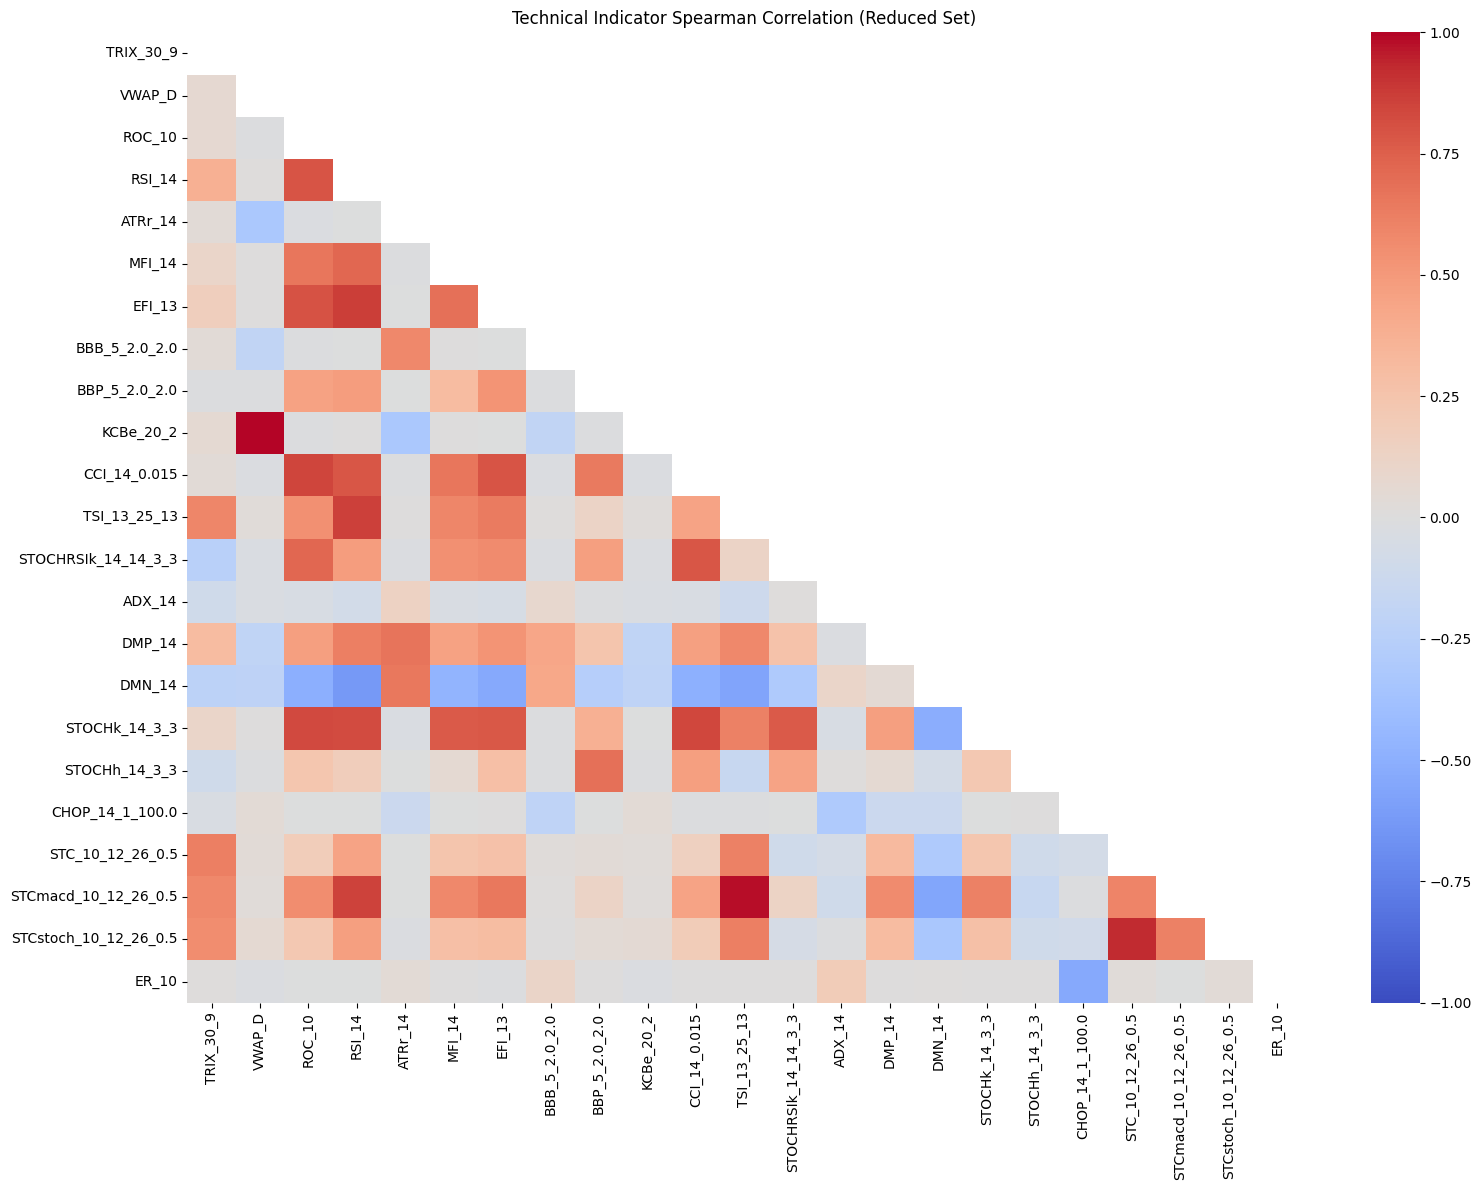

In [7]:
target_cols = [c for c in df.columns if "Target" in c or "LogRet" in c]
metadata_cols = ["Open", "High", "Low", "Close", "Volume"]
indicator_cols = [col for col in df.columns if col not in target_cols and col not in metadata_cols]

plt.figure(figsize=(16, 12))
corr_matrix = df[indicator_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Technical Indicator Spearman Correlation (Reduced Set)")
plt.tight_layout()
plt.show()